# Customer Segmentation Using RFM Analysis

This notebook groups known customers according to their purchase recency,
order frequency, and monetary value.

The purpose is to identify valuable, loyal, developing, and inactive customer
groups and suggest suitable business actions for each segment.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.ticker import FuncFormatter

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

processed_data_dir = (project_root/ "data"/ "processed")
reports_table_dir = (project_root/ "reports"/ "tables")
figures_dir = (project_root/ "reports"/ "figures")

reports_table_dir.mkdir(parents=True, exist_ok=True )
figures_dir.mkdir(parents=True, exist_ok=True)

customer_sales_path = (processed_data_dir/ "customer_sales.csv")

print(f"Project root: {project_root}")
print(
    "Customer sales available:",
    customer_sales_path.exists(),
)

Project root: c:\Users\ASUS\Python_workspace\retail_sales_insights
Customer sales available: True


## 1. Load Customer Sales Data

In [4]:
customer_sales_df = pd.read_csv(customer_sales_path, parse_dates = ["invoice_date","invoice_month"])

In [5]:
customer_sales_df["customer_id"] = (customer_sales_df["customer_id"].astype("Int64"))

In [6]:
customer_sales_df["invoice_no"] = customer_sales_df["invoice_no"].astype("string")
customer_sales_df["stock_code"] = customer_sales_df["stock_code"].astype("string")

In [7]:
customer_sales_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancelled,transaction_type,line_revenue,invoice_month,invoice_year,invoice_quarter,invoice_weekday,invoice_hour,invoice_day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,sale,15.30,2010-12-01,2010,4,Wednesday,8,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,sale,20.34,2010-12-01,2010,4,Wednesday,8,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,sale,22.00,2010-12-01,2010,4,Wednesday,8,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,sale,20.34,2010-12-01,2010,4,Wednesday,8,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,sale,20.34,2010-12-01,2010,4,Wednesday,8,2010-12-01


In [8]:
print(f"Rows: {len(customer_sales_df):,}")
print("Known customers:",f"{customer_sales_df['customer_id'].nunique():,}",)

Rows: 392,692
Known customers: 4,338


## 2. Validate the Input Data

In [9]:
required_columns = {
    "customer_id",
    "invoice_no",
    "invoice_date",
    "line_revenue",
    "quantity",
    "unit_price",
    "country",
}

assert required_columns.issubset(customer_sales_df.columns)
assert not customer_sales_df.empty
assert (customer_sales_df["customer_id"].notna().all())
assert (customer_sales_df["line_revenue"] > 0).all()
assert (customer_sales_df["quantity"] > 0).all()
assert (customer_sales_df["unit_price"] > 0).all()

print("Customer sales data is valid.")

Customer sales data is valid.


## 3. RFM Definitions

Each known customer will receive three measurements:

- **Recency:** Number of days between the reference date and the customer's
  most recent completed purchase. Lower values are better.
- **Frequency:** Number of unique completed invoices. Higher values are better.
- **Monetary:** Total completed-sales revenue. Higher values are better.

The reference date is one day after the final transaction date in the dataset.
This avoids comparing historical customers with the current calendar date.

In [10]:
last_dataset_date = (customer_sales_df["invoice_date"].max().normalize())

reference_date = (last_dataset_date + pd.Timedelta(days=1))

print("Last transaction date:", last_dataset_date.date())
print( "RFM reference date:", reference_date.date())

Last transaction date: 2011-12-09
RFM reference date: 2011-12-10


## 4. Calculate Customer-Level RFM Values

In [11]:
rfm_df = (
    customer_sales_df.groupby("customer_id",as_index=False,)
    .agg(
        last_purchase=("invoice_date","max"),
        first_purchase=("invoice_date","min"),
        frequency=("invoice_no","nunique"),
        monetary=("line_revenue","sum"),
        units_purchased=("quantity","sum"),
        unique_products=("stock_code","nunique"),
        country=("country","first"),
    )
)

In [12]:
rfm_df["recency"] = (reference_date- rfm_df["last_purchase"].dt.normalize()).dt.days

In [13]:
rfm_df["customer_lifetime_days"] = (rfm_df["last_purchase"].dt.normalize()- rfm_df["first_purchase"].dt.normalize()).dt.days

In [14]:
rfm_df.head()

,customer_id,last_purchase,first_purchase,frequency,monetary,units_purchased,unique_products,country,recency,customer_lifetime_days
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,1,United Kingdom,326,0
1,12347,2011-12-07 15:52:00,2010-12-07 14:57:00,7,4310.00,2458,103,Iceland,3,365
2,12348,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,2341,22,Finland,76,283
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,73,Italy,19,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,17,Norway,311,0


In [15]:
assert (len(rfm_df) == customer_sales_df["customer_id"].nunique())

print(f"Customer-level rows: {len(rfm_df):,}")

Customer-level rows: 4,338


In [16]:
rfm_df[["recency","frequency", "monetary"]].describe(percentiles=[0.25,0.50, 0.75, 0.90, 0.95,  0.99])

,recency,frequency,monetary
count,4338.000000,4338.000000,4338.000000
mean,93.059474,4.272015,2048.688081
std,100.012264,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.750000,5.000000,1660.597500
90%,263.300000,9.000000,3640.841000
95%,312.000000,13.000000,5789.999500
99%,369.630000,30.000000,19780.487800


In [17]:
one_time_customers = (rfm_df["frequency"] == 1).sum()
one_time_customer_share = (one_time_customers/ len(rfm_df)* 100)

print(f"One-time customers: {one_time_customers:,}")
print("One-time customer share:",f"{one_time_customer_share:.2f}%",)

One-time customers: 1,493
One-time customer share: 34.42%


## 5. Assign RFM Scores

Customers are divided into four approximately equal groups for each RFM
measurement.

A score of 4 represents the strongest result and a score of 1 represents the
weakest result.

In [18]:
rfm_df["r_score"] = pd.qcut(
    rfm_df["recency"].rank(method="first",ascending=True,),
    q=4,
    labels=[4, 3, 2, 1],
).astype(int)

In [19]:
rfm_df["f_score"] = pd.qcut(
    rfm_df["frequency"].rank(method="first", ascending=True),
    q=4,
    labels=[1, 2, 3, 4],
).astype(int)

In [20]:
rfm_df["m_score"] = pd.qcut(
    rfm_df["monetary"].rank(method="first", ascending=True),
    q=4,
    labels=[1, 2, 3, 4],
).astype(int)

In [21]:
rfm_df["rfm_total_score"] = (rfm_df["r_score"] + rfm_df["f_score"] + rfm_df["m_score"])

In [22]:
rfm_df["fm_score"] = (rfm_df["f_score"]+ rfm_df["m_score"]) / 2

In [23]:
rfm_df[["customer_id","recency","frequency","monetary", "r_score", "f_score", "m_score", "rfm_total_score",]].head(10)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_total_score
0,12346,326,1,77183.60,1,1,4,6
1,12347,3,7,4310.00,4,4,4,12
2,12348,76,4,1797.24,2,3,4,9
3,12349,19,1,1757.55,3,1,4,8
4,12350,311,1,334.40,1,1,2,4
5,12352,37,8,2506.04,3,4,4,11
6,12353,205,1,89.00,1,1,1,3
7,12354,233,1,1079.40,1,1,3,5
8,12355,215,1,459.40,1,1,2,4
9,12356,23,3,2811.43,3,3,4,10


In [24]:
assert rfm_df["r_score"].between(1, 4).all()
assert rfm_df["f_score"].between(1, 4).all()
assert rfm_df["m_score"].between(1, 4).all()

assert (rfm_df["rfm_total_score"].between(3, 12).all())

print("RFM scores are valid.")

RFM scores are valid.


In [25]:
print("Recency scores:")
print(rfm_df["r_score"].value_counts().sort_index())

print("\nFrequency scores:")
print(rfm_df["f_score"].value_counts().sort_index())

print("\nMonetary scores:")
print(rfm_df["m_score"].value_counts().sort_index())

Recency scores:
r_score
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64

Frequency scores:
f_score
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64

Monetary scores:
m_score
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64


## 6. Assign Customer Segments

The following business rules combine recency with frequency and monetary
performance:

- **Champions:** Very recent customers with high frequency and monetary value.
- **New Customers:** Very recent customers who have purchased only once.
- **Loyal Customers:** Recent customers with consistently strong purchasing.
- **Potential Loyalists:** Recent customers showing developing value.
- **At Risk:** Previously valuable customers who have not purchased recently.
- **Hibernating:** Inactive customers with low frequency and value.
- **Needs Attention:** Customers who do not clearly match another group.

These rules are practical business heuristics rather than predictive models.

In [26]:
conditions = [
    ((rfm_df["r_score"] == 4) & (rfm_df["fm_score"] >= 3.5)),
    ((rfm_df["r_score"] == 4)& (rfm_df["frequency"] == 1)),
    ((rfm_df["r_score"] >= 3)& (rfm_df["fm_score"] >= 3)),
    ((rfm_df["r_score"] >= 3)& (rfm_df["fm_score"] >= 2)),
    ((rfm_df["r_score"] <= 2)& (rfm_df["fm_score"] >= 3)),
    ((rfm_df["r_score"] <= 2)& (rfm_df["fm_score"] < 2)),
]

In [27]:
segment_labels = [
    "Champions",
    "New Customers",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk",
    "Hibernating",
]

In [28]:
rfm_df["segment"] = np.select(
    conditions,
    segment_labels,
    default="Needs Attention",
)

In [29]:
rfm_df["segment"].value_counts()

segment
Hibernating            1002
Needs Attention         965
Loyal Customers         692
Champions               649
At Risk                 489
Potential Loyalists     446
New Customers            95
Name: count, dtype: int64

In [30]:
segment_examples = rfm_df.sort_values(["segment","monetary",],ascending=[True,False])


In [31]:
segment_examples[
    [
        "customer_id",
        "segment",
        "recency",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score",
    ]
].head(20)

,customer_id,segment,recency,frequency,monetary,r_score,f_score,m_score
2502,15749,At Risk,236,3,44534.30,1,3,4
2011,15098,At Risk,183,3,39916.50,1,3,4
324,12744,At Risk,52,7,21279.29,2,4,4
459,12939,At Risk,65,8,11581.80,2,4,4
50,12409,At Risk,79,3,11072.67,2,3,4
2814,16180,At Risk,101,8,10254.18,2,4,4
196,12590,At Risk,212,2,9864.26,1,2,4
1903,14952,At Risk,60,11,8099.49,2,4,4
566,13093,At Risk,276,8,7832.47,1,4,4
73,12435,At Risk,80,2,7829.89,2,2,4


In [32]:
rfm_df.loc[rfm_df["segment"] == "At Risk",
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
    ],
].nlargest(10,"monetary")

,customer_id,recency,frequency,monetary
2502,15749,236,3,44534.30
2011,15098,183,3,39916.50
324,12744,52,7,21279.29
459,12939,65,8,11581.80
50,12409,79,3,11072.67
2814,16180,101,8,10254.18
196,12590,212,2,9864.26
1903,14952,60,11,8099.49
566,13093,276,8,7832.47
73,12435,80,2,7829.89


## 7. Segment Performance Summary

In [33]:
segment_summary = (rfm_df.groupby("segment",as_index=False)
    .agg(
        customers=("customer_id","nunique",),
        revenue=("monetary","sum"),
        average_recency=("recency","mean"),
        average_frequency=("frequency","mean"),
        average_customer_value=("monetary", "mean"),
        median_customer_value=( "monetary","median"),
        average_units=("units_purchased","mean")
    )
)

In [34]:
segment_summary["customer_share_pct"] = (segment_summary["customers"]/ segment_summary["customers"].sum()* 100)

In [35]:
segment_summary["revenue_share_pct"] = (segment_summary["revenue"]/ segment_summary["revenue"].sum()* 100)

In [36]:
segment_summary = (segment_summary.sort_values("revenue",ascending=False,).reset_index(drop=True))

In [37]:
segment_summary.round(2)

,segment,customers,revenue,average_recency,average_frequency,average_customer_value,median_customer_value,average_units,customer_share_pct,revenue_share_pct
0,Champions,649,4712279.95,7.98,13.02,7260.83,3078.58,4137.77,14.96,53.02
1,Loyal Customers,692,1981815.25,26.64,5.75,2863.89,1459.05,1663.97,15.95,22.30
2,At Risk,489,1047123.35,110.36,4.54,2141.36,1534.26,1195.07,11.27,11.78
3,Needs Attention,965,607550.46,116.99,1.74,629.59,443.60,418.15,22.25,6.84
4,Potential Loyalists,446,266995.89,23.33,2.30,598.65,546.70,363.92,10.28,3.00
5,Hibernating,1002,240737.70,201.44,1.07,240.26,213.62,143.85,23.10,2.71
6,New Customers,95,30706.29,10.28,1.00,323.22,245.10,218.64,2.19,0.35


In [38]:
assert (segment_summary["customers"].sum()== len(rfm_df))

assert np.isclose(segment_summary["customer_share_pct"].sum(),100)
assert np.isclose(segment_summary["revenue_share_pct"].sum(),100)

print("Segment summary is valid.")

Segment summary is valid.


In [39]:
largest_customer_segment =  segment_summary.loc[segment_summary["customers"].idxmax() ]

In [40]:
largest_revenue_segment = segment_summary.loc[segment_summary["revenue"].idxmax()]

In [41]:
print("Largest segment by customer count:",largest_customer_segment["segment"],)
print("Highest-revenue segment:",largest_revenue_segment["segment"],)

print("Highest-revenue segment share:", f"{largest_revenue_segment['revenue_share_pct']:.2f}%",)

Largest segment by customer count: Hibernating
Highest-revenue segment: Champions
Highest-revenue segment share: 53.02%


## 8. Segment Recommendations

In [42]:
recommendation_mapping = {
    "Champions": (
        "Reward and retain these customers with early access, "
        "loyalty benefits, and personalized offers."
    ),
    "Loyal Customers": (
        "Encourage repeat purchasing through loyalty rewards, "
        "bundles, and relevant cross-selling."
    ),
    "Potential Loyalists": (
        "Use follow-up campaigns and second-purchase incentives "
        "to develop these customers into loyal customers."
    ),
    "New Customers": (
        "Provide onboarding messages, product recommendations, "
        "and a time-limited second-order offer."
    ),
    "At Risk": (
        "Prioritize reactivation campaigns, especially for "
        "historically high-value customers."
    ),
    "Hibernating": (
        "Use low-cost re-engagement campaigns and avoid expensive "
        "discounts unless previous value justifies them."
    ),
    "Needs Attention": (
        "Review purchasing patterns and test targeted offers before "
        "assigning heavy marketing investment."
    ),
}

In [43]:
segment_summary["recommended_action"] = (
    segment_summary["segment"]
    .map(recommendation_mapping)
)

In [44]:
segment_recommendations = (
    segment_summary[
        [
            "segment",
            "customers",
            "customer_share_pct",
            "revenue",
            "revenue_share_pct",
            "average_recency",
            "average_frequency",
            "average_customer_value",
            "recommended_action",
        ]
    ]
    .copy()
)

In [45]:
def format_currency_axis(
    value: float,
    position: int,
) -> str:
    """Format currency values on chart axes."""

    if abs(value) >= 1_000_000:
        return f"£{value / 1_000_000:.1f}M"

    if abs(value) >= 1_000:
        return f"£{value / 1_000:.0f}K"

    return f"£{value:.0f}"

## 9. Customer Count by Segment

In [46]:
customer_segment_plot = (segment_summary.sort_values("customers").copy())

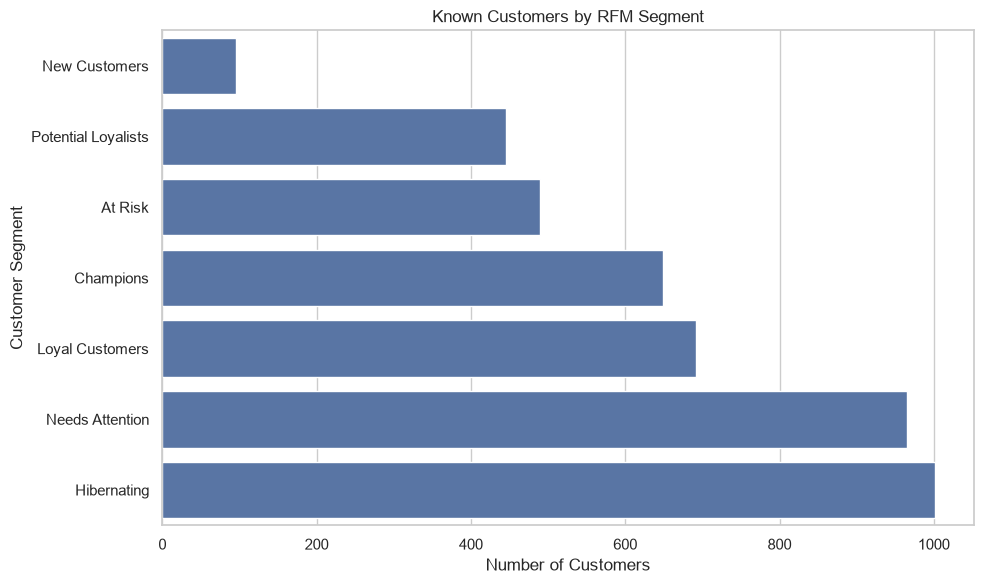

In [47]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

sns.barplot(
    data=customer_segment_plot,
    x="customers",
    y="segment",
    ax=ax,
)

ax.set_title("Known Customers by RFM Segment")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("Customer Segment")
fig.tight_layout()

customers_segment_path = (figures_dir/ "customers_by_segment.png")
fig.savefig(customers_segment_path, dpi=200,  bbox_inches="tight",)

plt.show()



### Interpretation

The largest customer segment was **Hibernating**, containing **1002 customers** and
representing **23.1%** of known customers.

A large segment is not automatically the most valuable segment. Customer
count should be compared with revenue contribution and average customer value.

## 10. Revenue by Segment

In [48]:
revenue_segment_plot = (segment_summary.sort_values("revenue") .copy())

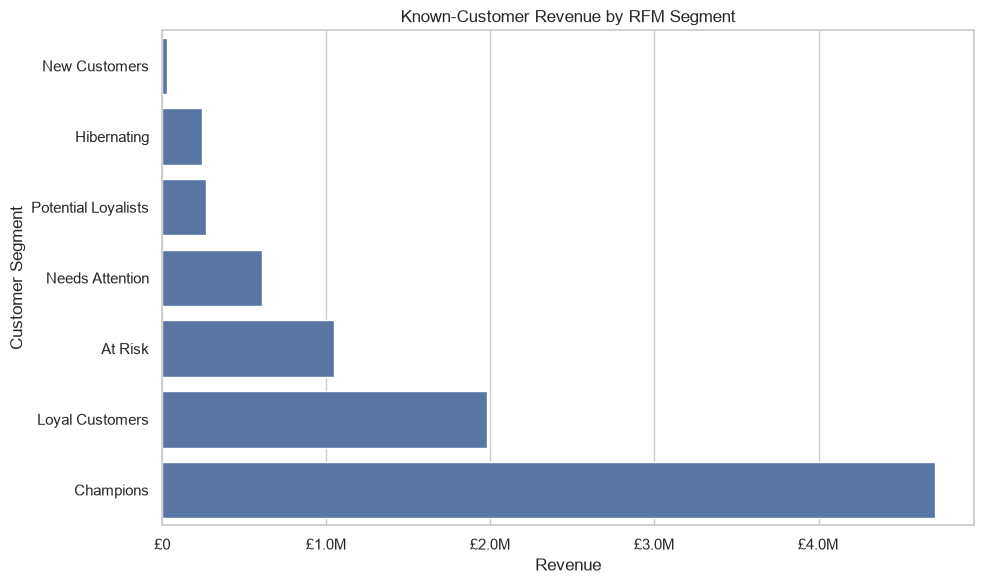

In [49]:
fig, ax = plt.subplots(figsize=(10, 6),)

sns.barplot(
    data=revenue_segment_plot,
    x="revenue",
    y="segment",
    ax=ax,
)

ax.set_title("Known-Customer Revenue by RFM Segment")
ax.set_xlabel("Revenue")
ax.set_ylabel(  "Customer Segment")
ax.xaxis.set_major_formatter( FuncFormatter(format_currency_axis))
fig.tight_layout()

revenue_segment_path = ( figures_dir /"revenue_by_segment.png")
fig.savefig(revenue_segment_path, dpi=200, bbox_inches="tight",)

plt.show()


### Interpretation

**Champions** generated the largest share of known-customer revenue at **53.02%**.

Segments with high revenue but poor recency require immediate attention
because losing these customers would create a larger financial impact than
losing low-value inactive customers.

In [50]:
champions = segment_summary.loc[ segment_summary["segment"] == "Champions"]
at_risk = segment_summary.loc[ segment_summary["segment"] == "At Risk"]
new_customers = segment_summary.loc[  segment_summary["segment"] == "New Customers"]

In [51]:
def get_segment_value(segment_df: pd.DataFrame, column: str, default: float = 0,) -> float:
    if segment_df.empty:
        return default

    return segment_df.iloc[0][column]

In [52]:
print(
    f"The highest-revenue segment was "
    f"{largest_revenue_segment['segment']}, "
    f"contributing "
    f"{largest_revenue_segment['revenue_share_pct']:.2f}% "
    f"of known-customer revenue."
)

print(
    f"Champions represented "
    f"{get_segment_value(champions, 'customer_share_pct'):.2f}% "
    f"of customers and "
    f"{get_segment_value(champions, 'revenue_share_pct'):.2f}% "
    f"of revenue."
)

print(
    f"At-risk customers represented "
    f"{get_segment_value(at_risk, 'customer_share_pct'):.2f}% "
    f"of customers and "
    f"{get_segment_value(at_risk, 'revenue_share_pct'):.2f}% "
    f"of revenue."
)

print(
    f"New customers represented "
    f"{get_segment_value(new_customers, 'customer_share_pct'):.2f}% "
    f"of customers."
)

The highest-revenue segment was Champions, contributing 53.02% of known-customer revenue.
Champions represented 14.96% of customers and 53.02% of revenue.
At-risk customers represented 11.27% of customers and 11.78% of revenue.
New customers represented 2.19% of customers.


## 11. Business Findings

1. **High-value customers:** The highest-revenue segment was **Champions**,
   contributing **53.02%** of known-customer revenue.

2. **Customer concentration:** Champions represented only **14.96%** of known
   customers but generated **53.02%** of known-customer revenue.

3. **Retention risk:** At-risk customers represented **11.27%** of customers and
   **11.78%** of revenue. Because these customers purchased frequently or spent
   heavily in the past, they should receive targeted reactivation campaigns.

4. **Customer development:** Potential loyalists represented **10.28%** of
   customers. Second-purchase incentives and personalized recommendations
   could help move them into loyal segments.

5. **New customers:** New customers represented **2.19%** of the customer base.
   An onboarding and follow-up process could improve repeat purchasing.

## 12. Export Segmentation Results

In [53]:
rfm_customer_path = (processed_data_dir/ "rfm_customers.csv")
segment_summary_path = (reports_table_dir/ "rfm_segment_summary.csv")
recommendations_path = ( reports_table_dir/ "segment_recommendations.csv")

In [54]:
rfm_df.to_csv(rfm_customer_path,index=False,)
segment_summary.to_csv(segment_summary_path,index=False,)
segment_recommendations.to_csv( recommendations_path, index=False,)

In [55]:
print( "RFM customers:", rfm_customer_path.exists())
print( "Segment summary:",  segment_summary_path.exists())
print( "Recommendations:",recommendations_path.exists())
print( "Customer chart:",customers_segment_path.exists())
print( "Revenue chart:", revenue_segment_path.exists(),)

RFM customers: True
Segment summary: True
Recommendations: True
Customer chart: True
Revenue chart: True


## 13. Conclusion

Known customers were grouped using Recency, Frequency, and Monetary value.

The segmentation distinguishes recent high-value customers, developing
customers, new customers, inactive customers, and previously valuable
customers who may be at risk.

The results show that customer count and revenue contribution are not always
distributed equally. Therefore, marketing and retention actions should be
prioritized according to both current activity and historical customer value.